In [ ]:
import numpy as np
from sklearn.tree import DecisionTreeClassifier,export_text
from sklearn.datasets import make_classification

In [ ]:
x,y=make_classification(
    n_samples=12,
    n_features=2,
    n_informative=2,
    random_state=42,
    n_redundant=0
)

In [ ]:
features_name=['Feature1','Feature2']

In [ ]:
print("dataset(first 8 features)")
for i in range(8):
    print(f"{features_name[0]}={x[i,0]:.2f}",
       f"{features_name[1]}={x[i,1]:.2f}",
       f"Class={y[i]}"
 )


dataset(first 8 features)
Feature1=-1.09 Feature2=-0.63 Class=0
Feature1=-0.94 Feature2=-1.36 Class=0
Feature1=-1.03 Feature2=0.30 Class=1
Feature1=-1.66 Feature2=2.89 Class=1
Feature1=0.10 Feature2=0.80 Class=1
Feature1=-0.55 Feature2=-2.59 Class=0
Feature1=3.00 Feature2=-0.15 Class=1
Feature1=-0.09 Feature2=0.91 Class=1


In [ ]:
tree=DecisionTreeClassifier(
    max_depth=3,
    criterion='entropy',
    random_state=42
)

In [ ]:
tree.fit(x,y)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [ ]:
print("decision tree structure")
print(export_text(tree,feature_names=features_name))

decision tree structure
|--- Feature2 <= -0.19
|   |--- class: 0
|--- Feature2 >  -0.19
|   |--- Feature1 <= 0.78
|   |   |--- class: 1
|   |--- Feature1 >  0.78
|   |   |--- Feature2 <= 0.15
|   |   |   |--- class: 1
|   |   |--- Feature2 >  0.15
|   |   |   |--- class: 0



In [ ]:
print("features importance")
for name,importance in zip(features_name,tree.feature_importances_):
  print(f"{name}:{importance:.3f}")


features importance
Feature1:0.116
Feature2:0.884


In [ ]:
import numpy as np
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,r2_score
from sklearn.tree import DecisionTreeRegressor


In [ ]:
X,y=make_moons(
    n_samples=500,
    random_state=42,
    noise=0.25
)

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

In [ ]:
depts_list=list(range(1,15))
train_acc=[]
test_acc=[]

for d in depts_list:
    model=DecisionTreeRegressor(
        max_depth=d,
        random_state=42
    )
    model.fit(X_train,y_train)
    train_acc.append(r2_score(y_train,model.predict(X_train)))
    test_acc.append(r2_score(y_test,model.predict(X_test)))

In [ ]:
test_acc
train_acc

[0.46265284423179165,
 0.7097376916868443,
 0.7398270494638532,
 0.7786710018288966,
 0.8930781959353388,
 0.9156050298907442,
 0.9503673469387754,
 0.9631746031746031,
 0.99,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0]

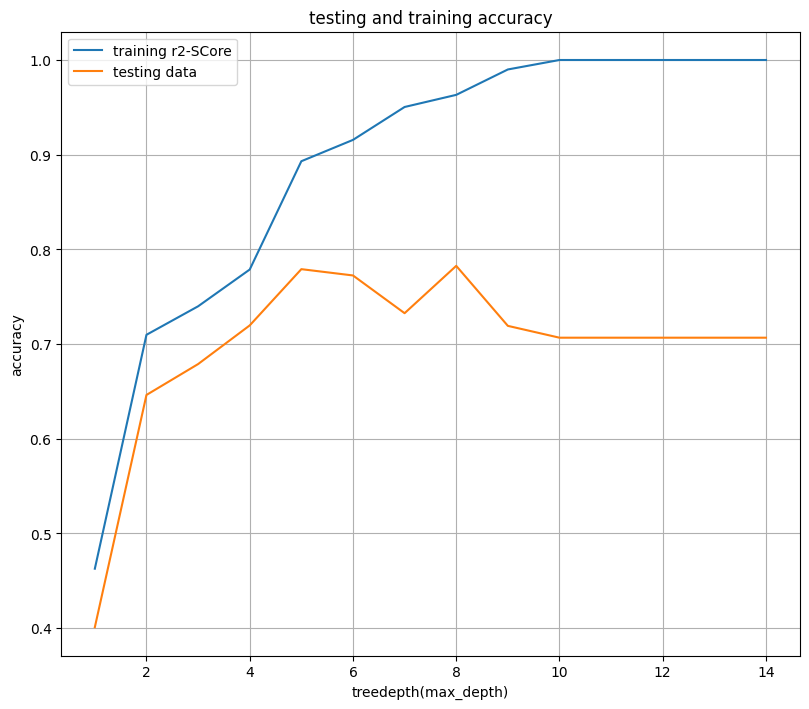

In [ ]:
plt.figure(figsize=(8,7))
plt.plot(depts_list,train_acc,label='training r2-SCore')
plt.plot(depts_list,test_acc,label='testing data')
plt.title("testing and training accuracy")
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.xlabel("treedepth(max_depth)")
plt.ylabel("accuracy")
plt.show()

In [ ]:
best_depth=depts_list[np.argmax(test_acc)]
print(f"the best depth of testing accuracy is:{best_depth}")


the best depth of testing accuracy is:8
